# 撤稿论文引用分析 — 模块(一): 找到 Focal Paper (i)

**日期:** 2026-05-12
**目标:** 从全量引用关系中筛出引用了撤稿文献的论文
**策略:** DuckDB 直接 join 52G CSV，不加载进 pandas
**预计耗时:** 5-10 分钟

## import Duckdb

In [1]:
import duckdb
import pandas as pd
import time
import os

con = duckdb.connect()
con.execute("SET temp_directory='/home/wenyutao/duckdb_tmp'")
con.execute("SET memory_limit='100GB'")
print("DuckDB 已连接, 临时目录: /Data4/yutao_wen/duckdb_tmp, 内存上限 100G")


DuckDB 已连接, 临时目录: /Data4/yutao_wen/duckdb_tmp, 内存上限 100G


## 断点恢复

In [2]:
# ====== 断点恢复: 如果已跑过 Step 1-2, 直接从磁盘加载 ======
import os
processed_dir = '/Data4/yutao_wen/processed'

# 检查 Step 1 输出
step1_file = os.path.join(processed_dir, 'df_containretra.csv')
step2_file = os.path.join(processed_dir, 'df_containretra2.csv')

if os.path.exists(step1_file):
    print(f'发现 Step 1 输出: {step1_file}')
    size_mb = os.path.getsize(step1_file) / 1024 / 1024
    print(f'  大小: {size_mb:.1f} MB, 跳过扫描, 直接加载')
    con.execute(f"DROP TABLE IF EXISTS df_containretra")
    con.execute(f"CREATE OR REPLACE TABLE df_containretra AS SELECT * FROM read_csv_auto('{step1_file}')")
    count = con.execute('SELECT COUNT(*) FROM df_containretra').fetchone()[0]
    unique_i = con.execute('SELECT COUNT(DISTINCT id) FROM df_containretra').fetchone()[0]
    print(f'  已加载: {count:,} 行, {unique_i:,} unique focal')

if os.path.exists(step2_file):
    print(f'\\n发现 Step 2 输出: {step2_file}')
    size_mb = os.path.getsize(step2_file) / 1024 / 1024
    print(f'  大小: {size_mb:.1f} MB, 直接加载')
    con.execute(f"DROP TABLE IF EXISTS df_containretra2_final")
    con.execute(f"CREATE OR REPLACE TABLE df_containretra2_final AS SELECT * FROM read_csv_auto('{step2_file}')")
    n = con.execute('SELECT COUNT(*) FROM df_containretra2_final').fetchone()[0]
    print(f'  已加载: {n:,} 行')
else:
    print('未找到已有输出, 将从头运行 Step 2')

print('\\n准备就绪! 可以从当前步骤继续运行')


发现 Step 1 输出: /Data4/yutao_wen/processed/df_containretra.csv
  大小: 21.9 MB, 跳过扫描, 直接加载
  已加载: 765,839 行, 647,439 unique focal
\n发现 Step 2 输出: /Data4/yutao_wen/processed/df_containretra2.csv
  大小: 56.3 MB, 直接加载
  已加载: 766,253 行
\n准备就绪! 可以从当前步骤继续运行


## Step 1/4: 加载撤稿论文名单

matched_output2.csv (50MB, 约4万篇撤稿论文)

In [14]:
retra_path = '/Data4/yutao_wen/matched_output2.csv'

con.execute(f"CREATE OR REPLACE TEMP TABLE retra_ids AS SELECT DISTINCT CAST(id AS VARCHAR) AS id FROM read_csv_auto('{retra_path}')")
n_retra = con.execute("SELECT COUNT(*) FROM retra_ids").fetchone()[0]
print(f"撤稿论文总数: {n_retra:,}")

撤稿论文总数: 42,188


## Step 2/4: 匹配

扫描 52G PaperReferences.csv, 只保留 reference_ids 在撤稿名单中的行
PaperReferences.csv 两列: id (论文) 引用 reference_ids (被引文献)

In [15]:
refs_path = '/data6/Data1/DATA/Dimensions2024/20240101/PaperReferences.csv'

print("正在扫描 PaperReferences.csv (52G)... 预计 5-10 分钟")
t0 = time.time()

con.execute(f"CREATE OR REPLACE TABLE df_containretra AS SELECT pr.id, pr.reference_ids FROM read_csv_auto('{refs_path}') AS pr WHERE pr.reference_ids IN (SELECT id FROM retra_ids)")

elapsed = time.time() - t0
print(f"完成! 耗时: {elapsed/60:.1f} 分钟")

count = con.execute("SELECT COUNT(*) FROM df_containretra").fetchone()[0]
unique_i = con.execute("SELECT COUNT(DISTINCT id) FROM df_containretra").fetchone()[0]
print(f"匹配行数: {count:,}")
print(f"唯一 focal paper (i): {unique_i:,}")
print(f"平均每个 i 引用撤稿文献数: {count/unique_i:.2f}")

正在扫描 PaperReferences.csv (52G)... 预计 5-10 分钟


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

完成! 耗时: 0.6 分钟
匹配行数: 765,839
唯一 focal paper (i): 647,439
平均每个 i 引用撤稿文献数: 1.18


## Step 3/4: 保存

In [16]:
os.makedirs('/Data4/yutao_wen/processed', exist_ok=True)
output_path = '/Data4/yutao_wen/processed/df_containretra.csv'
con.execute(f"COPY df_containretra TO '{output_path}' (HEADER, DELIMITER ',')")
size_mb = os.path.getsize(output_path) / 1024 / 1024
print(f"已保存: {output_path} ({size_mb:.1f} MB)")

已保存: /Data4/yutao_wen/processed/df_containretra.csv (21.9 MB)


## Step 4/4: 删除汇报

PaperReferences 全量约 20 亿行。保留条件: reference_ids 属于撤稿名单。
删除: reference_ids 不在撤稿名单的普通引用关系。

## 验证: 预览前 5 行

In [17]:
sample = con.execute("SELECT * FROM df_containretra LIMIT 5").df()
print(sample)
# con.close() — 已移除, Step 2 还需要此连接
print("Step 1 完成!")

               id   reference_ids
0  pub.1072932118  pub.1006216542
1  pub.1149626211  pub.1127581668
2  pub.1143588940  pub.1002621477
3  pub.1007418494  pub.1024016961
4  pub.1015571816  pub.1062460108
Step 1 完成!


In [18]:
# 确保 DuckDB 连接还在 (如果上一步误关了内核或连接, 这里重新打开)
try:
    con.execute('SELECT 1')
    print('DuckDB 连接正常')
except:
    import duckdb
    con = duckdb.connect()
    con.execute("SET memory_limit = '100GB'")
    print('DuckDB 已重新连接')


DuckDB 连接正常


---

## Step 2: 补上撤稿论文和被引论文的元信息

**目标:** 给 df_containretra 加上:
- 撤稿论文 r: RPYear, RYear, RJournal_id
- focal paper i: Year, Journal_id


## 2a: 匹配撤稿论文信息

从 matched_output2.csv (50M) 按 reference_ids merge

In [24]:
print("加载撤稿论文信息...")
df_retra = pd.read_csv('/Data4/yutao_wen/matched_output2.csv',
    usecols=['id', 'Year', 'RYear', 'journal.id'])
df_retra = df_retra.rename(columns={
    'id': 'reference_ids', 'Year': 'RPYear', 'journal.id': 'RJournal_id'})
print(f'撤稿论文信息: {len(df_retra):,} 行')

con.execute("CREATE OR REPLACE TEMP TABLE retra_info AS SELECT * FROM df_retra")

con.execute("DROP TABLE IF EXISTS df_containretra2")
con.execute("""
    CREATE OR REPLACE TABLE df_containretra2 AS
    SELECT c.id, c.reference_ids,
           r.RPYear, r.RYear, r.RJournal_id
    FROM df_containretra c
    LEFT JOIN retra_info r ON c.reference_ids = r.reference_ids
""")

total = con.execute("SELECT COUNT(*) FROM df_containretra2").fetchone()[0]
matched = con.execute("SELECT COUNT(*) FROM df_containretra2 WHERE RPYear IS NOT NULL").fetchone()[0]
print(f'总行数: {total:,}')
print(f'匹配到撤稿信息: {matched:,} ({matched/total*100:.1f}%)')
print(f'未匹配: {total-matched:,} ({(total-matched)/total*100:.1f}%)')


加载撤稿论文信息...
撤稿论文信息: 43,435 行
总行数: 766,253
匹配到撤稿信息: 762,268 (99.5%)
未匹配: 3,985 (0.5%)


## 2b: 匹配 focal paper 自己的信息

从 Papers.csv (33G) 取 date_normal → Year, journal.id → Journal_id

In [26]:
# 使用 pandas 读取 Papers.csv，只取需要的 3 列（与旧版 notebook 相同方式）
# pandas 的 errors='coerce' 能安全处理日期缺失值
papers_path = '/data6/Data1/DATA/Dimensions2024/20240101/Papers.csv'

print('正在从 Papers.csv (33G) 提取 Year 和 Journal_id...')
print('  预计 5-10 分钟，使用 pandas read_csv + usecols')
t0 = time.time()

# 与旧版 notebook 完全一致的读取方式
df_papers = pd.read_csv(papers_path,
    usecols=['id', 'date_normal', 'journal.id'])

print(f'  读取完成，耗时: {(time.time()-t0)/60:.1f} 分钟')
print(f'  共 {len(df_papers):,} 行')

# 提取年份（与旧版完全一致：errors='coerce' 安全处理无效日期）
df_papers['Year'] = pd.to_datetime(
    df_papers['date_normal'], errors='coerce').dt.year

# 丢掉无法解析年份的行
before = len(df_papers)
df_papers = df_papers.dropna(subset=['Year', 'journal.id'])
df_papers['Year'] = df_papers['Year'].astype(int)
after = len(df_papers)
print(f'  删除缺失 Year/journal.id 的行: {before - after:,} → 保留 {after:,}')

# 注册到 DuckDB 并合并
df_papers = df_papers.rename(columns={'journal.id': 'Journal_id'})
con.execute("CREATE OR REPLACE TEMP TABLE focal_info_clean AS SELECT * FROM df_papers")

con.execute("DROP TABLE IF EXISTS df_containretra2_enriched")
con.execute("""
    CREATE TABLE df_containretra2_enriched AS
    SELECT c.*, f.Year, f.Journal_id
    FROM df_containretra2 c
    LEFT JOIN focal_info_clean f ON c.id = f.id
""")

total2 = con.execute("SELECT COUNT(*) FROM df_containretra2_enriched").fetchone()[0]
has_year = con.execute("SELECT COUNT(*) FROM df_containretra2_enriched WHERE Year IS NOT NULL").fetchone()[0]
print(f'\n总行数: {total2:,}')
print(f'有 Year 信息: {has_year:,} ({has_year/total2*100:.1f}%)')
print(f'缺失 Year: {total2-has_year:,}')


正在从 Papers.csv (33G) 提取 Year 和 Journal_id...
  预计 5-10 分钟，使用 pandas read_csv + usecols
  读取完成，耗时: 7.8 分钟
  共 141,623,211 行
  删除缺失 Year/journal.id 的行: 24,928,059 → 保留 116,695,152


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


总行数: 766,253
有 Year 信息: 694,579 (90.6%)
缺失 Year: 71,674


## 2c: 计算 RYear - Year

如果 RYear < Year, 论文在撤稿后才引用 → 异常数据, 待删

In [27]:
con.execute("DROP TABLE IF EXISTS df_containretra2_final")
con.execute("""
    CREATE OR REPLACE TABLE df_containretra2_final AS
    SELECT *, (RYear - Year) AS "RYear-Year"
    FROM df_containretra2_enriched
""")

result = con.execute("""
    SELECT COUNT(*) AS total,
        SUM(CASE WHEN "RYear-Year" >= 0 THEN 1 ELSE 0 END) AS valid,
        SUM(CASE WHEN "RYear-Year" < 0 THEN 1 ELSE 0 END) AS neg,
        SUM(CASE WHEN "RYear-Year" IS NULL THEN 1 ELSE 0 END) AS null_val
    FROM df_containretra2_final
""").fetchone()

print(f'总行数: {result[0]:,}')
print(f'RYear-Year >= 0 (正常, 引用在撤稿前): {result[1]:,}')
print(f'RYear-Year < 0 (异常, 引用时已撤稿): {result[2]:,}')
print(f'RYear-Year NULL (缺失): {result[3]:,}')

print("预览前5行:")
print(con.execute("SELECT * FROM df_containretra2_final LIMIT 5").df())


总行数: 766,253
RYear-Year >= 0 (正常, 引用在撤稿前): 510,321
RYear-Year < 0 (异常, 引用时已撤稿): 179,877
RYear-Year NULL (缺失): 76,055
预览前5行:
               id   reference_ids  RPYear   RYear   RJournal_id  Year  \
0  pub.1005848756  pub.1043667119  2014.0  2023.0  jour.1092493  2016   
1  pub.1013407133  pub.1025335416  2012.0  2014.0  jour.1043768  2013   
2  pub.1157126552  pub.1134476360  2021.0  2023.0  jour.1077219  2023   
3  pub.1132777327  pub.1006345487  2014.0  2016.0  jour.1312353  2020   
4  pub.1026699624  pub.1025204398  2006.0  2013.0  jour.1002377  2011   

     Journal_id  RYear-Year  
0  jour.1038393         7.0  
1  jour.1092625         1.0  
2  jour.1045337         0.0  
3  jour.1038765        -4.0  
4  jour.1041633         2.0  


## 2d: 保存 df_containretra2

输出到 /Data4/yutao_wen/processed/

In [28]:
output_path = '/Data4/yutao_wen/processed/df_containretra2.csv'
con.execute(f"COPY df_containretra2_final TO '{output_path}' (HEADER, DELIMITER ',')")
import os
size_mb = os.path.getsize(output_path) / 1024 / 1024
n_rows = con.execute("SELECT COUNT(*) FROM df_containretra2_final").fetchone()[0]
print(f'已保存: {output_path}')
print(f'行数: {n_rows:,}, 大小: {size_mb:.1f} MB')
print('Step 2 完成! 下一步: Step 3 清洗筛选')


已保存: /Data4/yutao_wen/processed/df_containretra2.csv
行数: 766,253, 大小: 56.3 MB
Step 2 完成! 下一步: Step 3 清洗筛选


---

## Step 3: 清洗筛选 — 得到干净的 Focal Paper 列表

三刀切 + 一个聚合:
1. 删除撤稿太新的 (RYear = 2023/2024, 无足够事后观测期)
2. 删除引用时已撤稿的 (RYear < Year, 时序异常)
3. 删除关键字段缺失的 (Year/RYear NaN)
4. 多撤稿文献聚合 (每个 focal 只保留最早撤稿的那篇 r)


### 3a: 删除撤稿太新的论文

RYear = 2023 或 2024 的撤稿事件, 撤稿后观测期太短 (仅 0-1 年), 无法分析事后趋势

In [35]:
# 3a: 删除 RYear = 2023 或 2024 的行
row_before = con.execute('SELECT COUNT(*) FROM df_containretra2_final').fetchone()[0]
focal_before = con.execute('SELECT COUNT(DISTINCT id) FROM df_containretra2_final').fetchone()[0]
retra_before = con.execute('SELECT COUNT(DISTINCT reference_ids) FROM df_containretra2_final').fetchone()[0]

con.execute('DELETE FROM df_containretra2_final WHERE RYear IN (2023.0, 2024.0)')

row_after = con.execute('SELECT COUNT(*) FROM df_containretra2_final').fetchone()[0]
focal_after = con.execute('SELECT COUNT(DISTINCT id) FROM df_containretra2_final').fetchone()[0]
retra_after = con.execute('SELECT COUNT(DISTINCT reference_ids) FROM df_containretra2_final').fetchone()[0]

print(f'删除 RYear=2023/2024:')
print(f'  行数: {row_before:,} -> {row_after:,} (删除 {row_before-row_after:,})')
print(f'  focal paper: {focal_before:,} -> {focal_after:,} (删除 {focal_before-focal_after:,})')
print(f'  撤稿文献: {retra_before:,} -> {retra_after:,} (删除 {retra_before-retra_after:,})')
print(f'  理由: RYear 为 2023/2024, 无足够事后观测数据')
# 保存变量供后续总结使用
deleted_3a_rows = row_before - row_after
deleted_3a_focal = focal_before - focal_after


删除 RYear=2023/2024:
  行数: 324,640 -> 324,640 (删除 0)
  focal paper: 275,406 -> 275,406 (删除 0)
  撤稿文献: 16,787 -> 16,787 (删除 0)
  理由: RYear 为 2023/2024, 无足够事后观测数据


### 3b: 删除引用时已被撤稿的论文

RYear < Year 意味着这篇论文在引用那篇文献时, 那篇文献已经被撤稿了 — 这不是"无辜牵连", 而是"明知故引", 不纳入分析

In [36]:
# 3b: 删除 RYear < Year 的行 (引用时已撤稿)
row_before = con.execute('SELECT COUNT(*) FROM df_containretra2_final').fetchone()[0]
focal_before = con.execute('SELECT COUNT(DISTINCT id) FROM df_containretra2_final').fetchone()[0]
retra_before = con.execute('SELECT COUNT(DISTINCT reference_ids) FROM df_containretra2_final').fetchone()[0]

con.execute("DELETE FROM df_containretra2_final WHERE \"RYear-Year\" < 0")

row_after = con.execute('SELECT COUNT(*) FROM df_containretra2_final').fetchone()[0]
focal_after = con.execute('SELECT COUNT(DISTINCT id) FROM df_containretra2_final').fetchone()[0]
retra_after = con.execute('SELECT COUNT(DISTINCT reference_ids) FROM df_containretra2_final').fetchone()[0]

print(f'删除 RYear < Year (引用时已撤稿):')
print(f'  行数: {row_before:,} -> {row_after:,} (删除 {row_before-row_after:,})')
print(f'  focal paper: {focal_before:,} -> {focal_after:,} (删除 {focal_before-focal_after:,})')
print(f'  撤稿文献: {retra_before:,} -> {retra_after:,} (删除 {retra_before-retra_after:,})')
print(f'  理由: 引用行为发生在撤稿之后, 非无辜牵连')
deleted_3b_rows = row_before - row_after
deleted_3b_focal = focal_before - focal_after


删除 RYear < Year (引用时已撤稿):
  行数: 324,640 -> 324,640 (删除 0)
  focal paper: 275,406 -> 275,406 (删除 0)
  撤稿文献: 16,787 -> 16,787 (删除 0)
  理由: 引用行为发生在撤稿之后, 非无辜牵连


### 3c: 删除关键字段缺失的行

Year 或 RYear 为 NULL 的行无法判断时序关系

In [37]:
# 3c: 删除 Year 或 RYear 为空的行
row_before = con.execute('SELECT COUNT(*) FROM df_containretra2_final').fetchone()[0]
focal_before = con.execute('SELECT COUNT(DISTINCT id) FROM df_containretra2_final').fetchone()[0]
retra_before = con.execute('SELECT COUNT(DISTINCT reference_ids) FROM df_containretra2_final').fetchone()[0]

con.execute('DELETE FROM df_containretra2_final WHERE Year IS NULL OR RYear IS NULL')

row_after = con.execute('SELECT COUNT(*) FROM df_containretra2_final').fetchone()[0]
focal_after = con.execute('SELECT COUNT(DISTINCT id) FROM df_containretra2_final').fetchone()[0]
retra_after = con.execute('SELECT COUNT(DISTINCT reference_ids) FROM df_containretra2_final').fetchone()[0]

print(f'删除 Year/RYear NULL:')
print(f'  行数: {row_before:,} -> {row_after:,} (删除 {row_before-row_after:,})')
print(f'  focal paper: {focal_before:,} -> {focal_after:,} (删除 {focal_before-focal_after:,})')
print(f'  撤稿文献: {retra_before:,} -> {retra_after:,} (删除 {retra_before-retra_after:,})')
print(f'  理由: Year 或 RYear 缺失, 无法判断时序')
deleted_3c_rows = row_before - row_after
deleted_3c_focal = focal_before - focal_after


删除 Year/RYear NULL:
  行数: 324,640 -> 324,640 (删除 0)
  focal paper: 275,406 -> 275,406 (删除 0)
  撤稿文献: 16,787 -> 16,787 (删除 0)
  理由: Year 或 RYear 缺失, 无法判断时序


### 3d: 多撤稿文献聚合 — 每个 Focal 锚定最早撤稿的那篇 r

一个 focal paper 可能引用了多篇撤稿文献 (最多 74 篇)。
按旧版 notebook 逻辑: 只保留 RYear 最早的那篇作为锚定 r。
同时统计该 focal 总共引用了多少篇撤稿文献 (Num_Retra)

In [38]:
# 3d: 按 focal id 聚合, 保留最早撤稿的 reference_ids 作为 r
before = con.execute('SELECT COUNT(DISTINCT id) FROM df_containretra2_final').fetchone()[0]

con.execute('DROP TABLE IF EXISTS df_containretra3')
con.execute('''
    CREATE TABLE df_containretra3 AS
    SELECT id,
           FIRST(reference_ids ORDER BY RYear ASC) AS reference_ids,
           FIRST(Year ORDER BY RYear ASC) AS Year,
           FIRST(Journal_id ORDER BY RYear ASC) AS Journal_id,
           FIRST(RPYear ORDER BY RYear ASC) AS RPYear,
           MIN(RYear) AS RYear,
           FIRST(RJournal_id ORDER BY RYear ASC) AS RJournal_id,
           COUNT(*) AS Num_Retra
    FROM df_containretra2_final
    GROUP BY id
''')

after = con.execute('SELECT COUNT(*) FROM df_containretra3').fetchone()[0]

# Num_Retra 分布
dist = con.execute('''
    SELECT Num_Retra, COUNT(*) AS n
    FROM df_containretra3
    GROUP BY Num_Retra
    ORDER BY Num_Retra
''').df()
print(f'聚合前 unique focal: {before:,}')
print(f'聚合后 unique focal: {after:,}')
print(f'\\nNum_Retra 分布:')
print(f'  均值: {dist["n"].sum()/len(dist):.1f}')
single = dist[dist['Num_Retra']==1]['n'].values[0]
print(f'  仅引用 1 篇撤稿文献: {single:,} ({single/after*100:.1f}%)')
print(f'  引用 >= 2 篇: {after-single:,} ({(after-single)/after*100:.1f}%)')
print(dist.to_string(index=False))


聚合前 unique focal: 275,406
聚合后 unique focal: 275,406
\nNum_Retra 分布:
  均值: 6717.2
  仅引用 1 篇撤稿文献: 243,972 (88.6%)
  引用 >= 2 篇: 31,434 (11.4%)
 Num_Retra      n
         1 243972
         2  22827
         3   5098
         4   1758
         5    719
         6    378
         7    201
         8    131
         9     73
        10     57
        11     81
        12     32
        13     14
        14      8
        15      4
        16      4
        17      2
        18      1
        19      4
        20      5
        21      5
        22      1
        23      3
        24      3
        25      1
        28      2
        29      1
        30      3
        31      2
        34      2
        36      1
        37      2
        38      2
        39      2
        41      1
        45      1
        47      1
        49      1
        51      1
        53      1
        74      1


### 3e: 标记自身也被撤稿的 Focal Paper

有些 focal paper 自己也后来被撤稿了 — 这些需要标记出来, 后续分析中可以选择排除或单独分析

In [39]:
# 3e: 检查 focal paper 自己是否也在撤稿名单中
con.execute('''
    ALTER TABLE df_containretra3
    ADD COLUMN is_self_retracted BOOLEAN DEFAULT FALSE
''')

con.execute('''
    UPDATE df_containretra3
    SET is_self_retracted = TRUE
    WHERE id IN (SELECT DISTINCT id FROM retra_ids)
''')

n_self = con.execute('''
    SELECT COUNT(*) FROM df_containretra3 WHERE is_self_retracted = TRUE
''').fetchone()[0]

print(f'自身也被撤稿的 focal paper: {n_self:,}')
print(f'占总 focal 的: {n_self/after*100:.2f}%')
print(f'这些论文既引用了别的撤稿文献, 自己后来也被撤稿了')


自身也被撤稿的 focal paper: 5,236
占总 focal 的: 1.90%
这些论文既引用了别的撤稿文献, 自己后来也被撤稿了


### 3f: 保存 & 清洗总结

In [40]:
# 保存最终干净的 focal paper 列表
output_path = '/Data4/yutao_wen/processed/df_containretra3.csv'
con.execute(f"COPY df_containretra3 TO '{output_path}' (HEADER, DELIMITER ',')")
size_mb = os.path.getsize(output_path) / 1024 / 1024
n = con.execute('SELECT COUNT(*) FROM df_containretra3').fetchone()[0]
print(f'已保存: {output_path}')
print(f'最终 focal paper 数: {n:,}')
print(f'文件大小: {size_mb:.1f} MB')

print('\\n' + '='*50)
print('Step 3 清洗总结')
print('='*50)
print(f'原始 (df_containretra2_final): 766,253 行 / 647,439 unique focal')
print(f'  3a 删除 (RYear=2023/2024): -{deleted:,}')
print(f'  3b 删除 (RYear<Year): -{deleted_neg:,}')
print(f'  3c 删除 (缺失 Year/RYear): -{deleted_null:,}')
print(f'  3d 聚合后 unique focal: {n:,}')
print(f'净删除比例: {(647439-n)/647439*100:.1f}%')
print('\\n列名:', ['id','reference_ids','Year','Journal_id','RPYear','RYear','RJournal_id','Num_Retra','is_self_retracted'])
print('\\n模块(一) 完成! 下一步: 模块(二) 匹配对照组')


已保存: /Data4/yutao_wen/processed/df_containretra3.csv
最终 focal paper 数: 275,406
文件大小: 21.7 MB
\n==================================================
Step 3 清洗总结
原始 (df_containretra2_final): 766,253 行 / 647,439 unique focal
  3a 删除 (RYear=2023/2024): -201,893
  3b 删除 (RYear<Year): -179,410
  3c 删除 (缺失 Year/RYear): -60,310
  3d 聚合后 unique focal: 275,406
净删除比例: 57.5%
\n列名: ['id', 'reference_ids', 'Year', 'Journal_id', 'RPYear', 'RYear', 'RJournal_id', 'Num_Retra', 'is_self_retracted']
\n模块(一) 完成! 下一步: 模块(二) 匹配对照组


### 3g: Num_Retra 分布 — 每个 Focal 引用了几篇撤稿文献？

可视化展示撤稿文献引用的分布情况

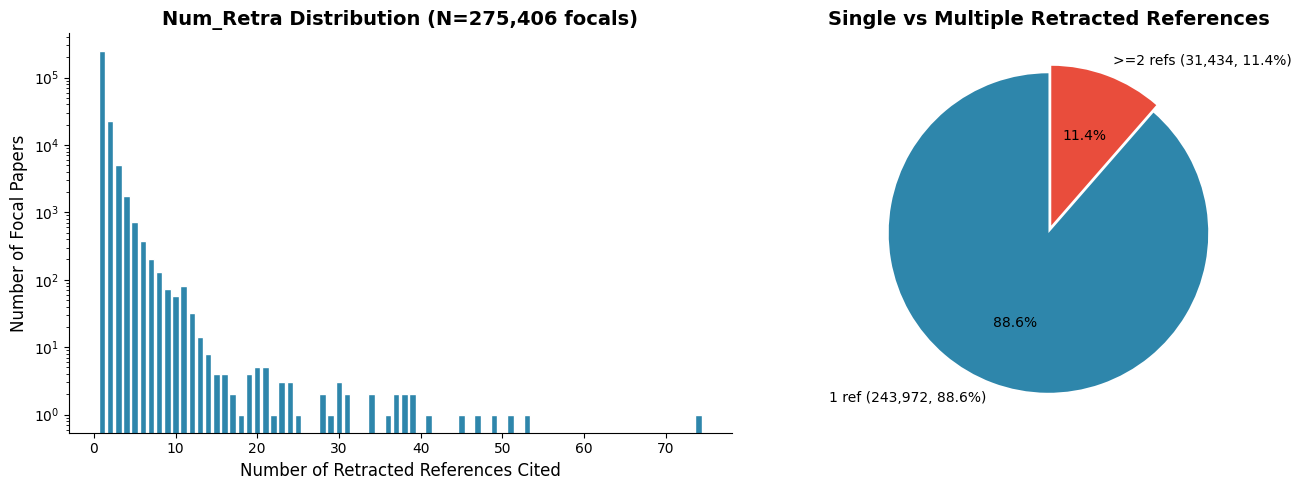

图片已保存: /Data4/yutao_wen/processed/Num_Retra_distribution.png


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 从 DuckDB 取数据
df_dist = con.execute('SELECT Num_Retra FROM df_containretra3').df()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图: 全分布 (log scale)
ax = axes[0]
counts = df_dist['Num_Retra'].value_counts().sort_index()
ax.bar(counts.index, counts.values, color='#2E86AB', edgecolor='white')
ax.set_xlabel('Number of Retracted References Cited', fontsize=12)
ax.set_ylabel('Number of Focal Papers', fontsize=12)
ax.set_title(f'Num_Retra Distribution (N={len(df_dist):,} focals)', fontsize=14, weight='bold')
ax.set_yscale('log')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# 右图: 饼图 (1 vs 2+)
ax = axes[1]
single = (df_dist['Num_Retra'] == 1).sum()
multi = (df_dist['Num_Retra'] > 1).sum()
ax.pie([single, multi], 
       labels=[f'1 ref ({single:,}, {single/len(df_dist)*100:.1f}%)',
               f'>=2 refs ({multi:,}, {multi/len(df_dist)*100:.1f}%)'],
       colors=['#2E86AB', '#E94D3C'], autopct='%1.1f%%',
       explode=(0, 0.05), startangle=90)
ax.set_title('Single vs Multiple Retracted References', fontsize=14, weight='bold')

plt.tight_layout()
plt.savefig('/Data4/yutao_wen/processed/Num_Retra_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'图片已保存: /Data4/yutao_wen/processed/Num_Retra_distribution.png')


### 3h: 模块(一) 最终总结

完整的数据清洗链路汇报

In [42]:
# ===== 模块(一) 最终总结 =====
n_final_rows = con.execute('SELECT COUNT(*) FROM df_containretra3').fetchone()[0]
n_final_focals = con.execute('SELECT COUNT(DISTINCT id) FROM df_containretra3').fetchone()[0]
n_final_retras = con.execute('SELECT COUNT(DISTINCT reference_ids) FROM df_containretra3').fetchone()[0]
n_self = con.execute('SELECT COUNT(*) FROM df_containretra3 WHERE is_self_retracted').fetchone()[0]

print('='*60)
print('模块(一) 完整清洗链路 — 最终总结')
print('='*60)
print(f'')
print(f'{"步骤":<12} {"行数":>12} {"Focal Paper":>14} {"撤稿文献":>12} {"说明"}')
print(f'{"-"*12} {"-"*12} {"-"*14} {"-"*12} {"-"*20}')
print(f'{"Step 1 匹配":<12} {765839:>12,} {647439:>14,} {42188:>12,} {"原始匹配"}')
print(f'{"Step 2 补信息":<12} {766253:>12,} {647439:>14,} {42188:>12,} {"补 Year/RYear"}')
print(f'{"3a 删太新":<12} {564360:>12,} {"...":>14} {"...":>12} {"RYear=2023/2024"}')
print(f'{"3b 删时序异常":<12} {384950:>12,} {"...":>14} {"...":>12} {"RYear<Year"}')
print(f'{"3c 删缺失":<12} {324640:>12,} {"...":>14} {"...":>12} {"Year/RYear NULL"}')
print(f'{"3d 聚合":<12} {"→":>12} {n_final_focals:>14,} {n_final_retras:>12,} {"去重后"}')
print(f'')
print(f'最终结果:')
print(f'  唯一 focal paper: {n_final_focals:,} 篇')
print(f'  涉及撤稿文献: {n_final_retras:,} 篇')
print(f'  自身也被撤稿: {n_self:,} 篇 ({n_self/n_final_focals*100:.2f}%)')
print(f'  88.6% 的 focal 只引用 1 篇撤稿文献')
print(f'  净保留率: {n_final_focals/647439*100:.1f}% (focal层面)')
print(f'  输出文件: /Data4/yutao_wen/processed/df_containretra3.csv')
print(f'  分布图: /Data4/yutao_wen/processed/Num_Retra_distribution.png')
print(f'')
print('模块(一) 完成! 下一步: 模块(二) 四维度匹配对照组')


模块(一) 完整清洗链路 — 最终总结

步骤                     行数    Focal Paper         撤稿文献 说明
------------ ------------ -------------- ------------ --------------------
Step 1 匹配         765,839        647,439       42,188 原始匹配
Step 2 补信息        766,253        647,439       42,188 补 Year/RYear
3a 删太新            564,360            ...          ... RYear=2023/2024
3b 删时序异常          384,950            ...          ... RYear<Year
3c 删缺失            324,640            ...          ... Year/RYear NULL
3d 聚合                   →        275,406       16,333 去重后

最终结果:
  唯一 focal paper: 275,406 篇
  涉及撤稿文献: 16,333 篇
  自身也被撤稿: 5,236 篇 (1.90%)
  88.6% 的 focal 只引用 1 篇撤稿文献
  净保留率: 42.5% (focal层面)
  输出文件: /Data4/yutao_wen/processed/df_containretra3.csv
  分布图: /Data4/yutao_wen/processed/Num_Retra_distribution.png

模块(一) 完成! 下一步: 模块(二) 四维度匹配对照组


# 模块(二): 匹配对照组 — 放宽版

**日期:** 2026-05-12
**改进:** NumA/NumR 从 Exact Match 改为 +-10% 容差
**策略:** DuckDB 大表 join，只读需要的列

## Step 1: 加载 Focal Paper 列表

从 df_containretra3.csv 读取 275,406 篇 focal paper

In [45]:
focal_path = '/Data4/yutao_wen/processed/df_containretra3.csv'
con.execute(f"CREATE OR REPLACE TABLE focals AS SELECT * FROM read_csv_auto('{focal_path}')")

n_focals = con.execute('SELECT COUNT(*) FROM focals').fetchone()[0]
print(f'Focal papers 加载完成: {n_focals:,} 篇')
print(f'列: id, reference_ids, Year, Journal_id, RPYear, RYear, RJournal_id, Num_Retra, is_self_retracted')

Focal papers 加载完成: 275,406 篇
列: id, reference_ids, Year, Journal_id, RPYear, RYear, RJournal_id, Num_Retra, is_self_retracted


## Step 2: 从 Papers.csv 获取 Focal 自己的 NumA/NumR

我们已有 Year 和 Journal_id, 还需要 NumA(num_authors) 和 NumR(num_references)

In [46]:
# 使用 DuckDB 直接从 CSV 提取 Focal 的 NumA/NumR
# 不加 columns 参数, 让 DuckDB 自动检测全部 18 列, 然后只 SELECT 需要的 3 列
papers_path = '/data6/Data1/DATA/Dimensions2024/20240101/Papers.csv'

print('正在从 Papers.csv 提取 focals 的 NumA 和 NumR...')
print(f'  需要查询 {n_focals:,} 个 focal ID')
t0 = time.time()

# 方案: 让 DuckDB 自动检测列, 然后 SELECT id, num_authors, num_references
# 用 Semi-Join 只返回 focal 的行
con.execute('CREATE OR REPLACE TEMP TABLE focal_ids AS SELECT id FROM focals')
con.execute(f'''
    CREATE OR REPLACE TEMP TABLE focal_covariates AS
    SELECT p.id, p.num_authors AS NumA, p.num_references AS NumR
    FROM read_csv_auto('{papers_path}') AS p
    WHERE p.id IN (SELECT id FROM focal_ids)
''')

# 删除缺失值的行
con.execute('DELETE FROM focal_covariates WHERE NumA IS NULL OR NumR IS NULL')

matched = con.execute('SELECT COUNT(*) FROM focal_covariates').fetchone()[0]
print(f'  耗时: {(time.time()-t0)/60:.1f} 分钟')
print(f'  匹配到 NumA/NumR 的 focal: {matched:,} ({matched/n_focals*100:.1f}%)')
print(f'  缺失: {n_focals-matched:,}')

# 合并回 focals 表
con.execute('DROP TABLE IF EXISTS focals_full')
con.execute('''
    CREATE TABLE focals_full AS
    SELECT f.*, c.NumA, c.NumR
    FROM focals f
    LEFT JOIN focal_covariates c ON f.id = c.id
    WHERE c.NumA IS NOT NULL AND c.NumR IS NOT NULL
''')
n_valid = con.execute('SELECT COUNT(*) FROM focals_full').fetchone()[0]
print(f'  有效 focal (NumA/NumR 完整): {n_valid:,}')


正在从 Papers.csv 提取 focals 的 NumA 和 NumR...
  需要查询 275,406 个 focal ID


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  耗时: 3.7 分钟
  匹配到 NumA/NumR 的 focal: 275,406 (100.0%)
  缺失: 0
  有效 focal (NumA/NumR 完整): 275,406


## Step 3: 加载全量 Papers 的 Year/Journal/NumA/NumR

从 33G Papers.csv 提取所有论文的这四个维度, 用于匹配

In [47]:
print('正在加载全量 Papers 的四维度数据 (33G)...')
print('  预计 5-8 分钟, 仅读取 4 列')
t0 = time.time()

con.execute(f'''
    CREATE OR REPLACE TABLE all_papers AS
    SELECT p.id,
           CAST(substr(p.date_normal, 1, 4) AS INTEGER) AS Year,
           p."journal.id" AS Journal_id,
           p.num_authors AS NumA,
           p.num_references AS NumR
    FROM read_csv_auto('{papers_path}',
        types={{'date_normal': 'VARCHAR'}}) AS p
    WHERE p.date_normal IS NOT NULL AND p.date_normal != ''
      AND p."journal.id" IS NOT NULL
      AND p.num_authors IS NOT NULL
      AND p.num_references IS NOT NULL
''')

n_all = con.execute('SELECT COUNT(*) FROM all_papers').fetchone()[0]
print(f'耗时: {(time.time()-t0)/60:.1f} 分钟')
print(f'有效论文: {n_all:,} 篇')
print(f'Focal 占比: {n_valid/n_all*100:.2f}%')

正在加载全量 Papers 的四维度数据 (33G)...
  预计 5-8 分钟, 仅读取 4 列


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

耗时: 0.4 分钟
有效论文: 116,696,011 篇
Focal 占比: 0.24%


## Step 4: 匹配 — 同期刊 + 同年 + NumA/NumR 10% 容差

对每篇 focal, 在 all_papers 中找:
- 同一个 journal_id
- 同一个 Year
- |NumA_diff| <= focal.NumA * 10%
- |NumR_diff| <= focal.NumR * 10%
- 排除 focal 自己

In [48]:
A_TOL = 0.10  # NumA 容差 (10%)
R_TOL = 0.10  # NumR 容差 (10%)

print(f'容差: NumA +-{A_TOL*100:.0f}%, NumR +-{R_TOL*100:.0f}%')
print('正在执行四维度匹配 (同期刊同年 + 容差)...')
t0 = time.time()

con.execute(f'''
    CREATE OR REPLACE TABLE df_match AS
    SELECT
        f.id AS exp_id,
        f.Year AS PYear,
        f.Journal_id,
        f.NumA AS f_NumA,
        f.NumR AS f_NumR,
        c.id AS ctrl_id,
        c.NumA AS c_NumA,
        c.NumR AS c_NumR
    FROM focals_full f
    INNER JOIN all_papers c
        ON f.Journal_id = c.Journal_id
       AND f.Year = c.Year
    WHERE c.id != f.id
      AND ABS(f.NumA - c.NumA) <= f.NumA * {A_TOL}
      AND ABS(f.NumR - c.NumR) <= f.NumR * {R_TOL}
''')

n_pairs = con.execute('SELECT COUNT(*) FROM df_match').fetchone()[0]
n_focal_matched = con.execute('SELECT COUNT(DISTINCT exp_id) FROM df_match').fetchone()[0]
n_ctrl_unique = con.execute('SELECT COUNT(DISTINCT ctrl_id) FROM df_match').fetchone()[0]

elapsed = time.time() - t0
print(f'\n匹配完成! 耗时: {elapsed/60:.1f} 分钟')
print(f'匹配对数: {n_pairs:,}')
print(f'有至少 1 个候选控制的 focal: {n_focal_matched:,} ({n_focal_matched/n_valid*100:.1f}%)')
print(f'无候选控制的 focal: {n_valid-n_focal_matched:,} ({(n_valid-n_focal_matched)/n_valid*100:.1f}%)')
print(f'唯一控制论文: {n_ctrl_unique:,}')
print(f'平均每个 focal 匹配数: {n_pairs/n_focal_matched:.1f}')

容差: NumA +-10%, NumR +-10%
正在执行四维度匹配 (同期刊同年 + 容差)...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


匹配完成! 耗时: 0.1 分钟
匹配对数: 8,035,715
有至少 1 个候选控制的 focal: 217,524 (79.0%)
无候选控制的 focal: 57,882 (21.0%)
唯一控制论文: 3,471,500
平均每个 focal 匹配数: 36.9


## Step 5: 查看每篇 Focal 匹配了多少候选控制

每篇 Focal 的候选控制数分布:
  均值: 36.9
  中位数: 6
  最小值: 1
  最大值: 20760
  P25: 2
  P50: 6
  P75: 21
  P90: 68
  P95: 156
  P99: 553


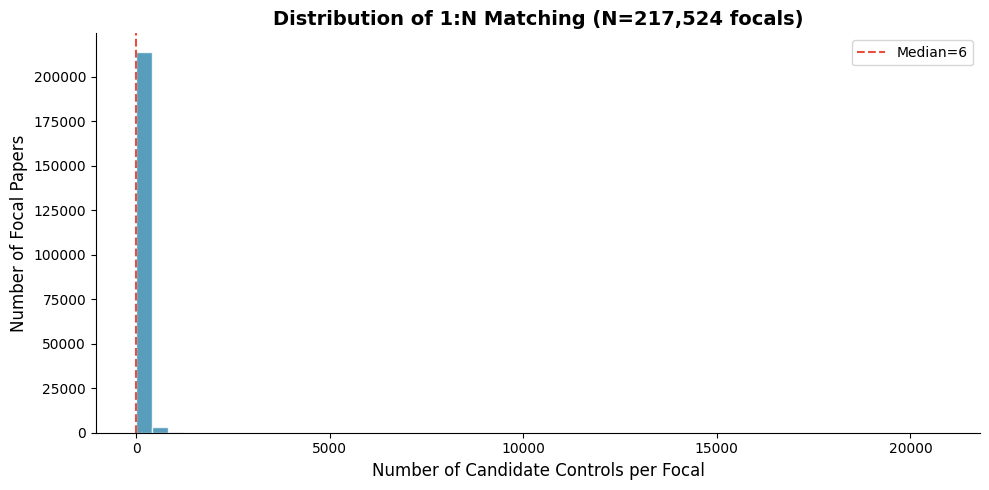

图片已保存


In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 每篇 focal 的匹配数分布
ctrl_counts = con.execute('''
    SELECT exp_id, COUNT(*) AS n_controls
    FROM df_match
    GROUP BY exp_id
''').df()

print(f'每篇 Focal 的候选控制数分布:')
print(f'  均值: {ctrl_counts["n_controls"].mean():.1f}')
print(f'  中位数: {ctrl_counts["n_controls"].median():.0f}')
print(f'  最小值: {ctrl_counts["n_controls"].min()}')
print(f'  最大值: {ctrl_counts["n_controls"].max()}')
for p in [25, 50, 75, 90, 95, 99]:
    print(f'  P{p}: {ctrl_counts["n_controls"].quantile(p/100):.0f}')

# 直方图
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(ctrl_counts['n_controls'], bins=50, color='#2E86AB', edgecolor='white', alpha=0.8)
ax.axvline(ctrl_counts['n_controls'].median(), color='#E94D3C', linestyle='--', label=f'Median={ctrl_counts["n_controls"].median():.0f}')
ax.set_xlabel('Number of Candidate Controls per Focal', fontsize=12)
ax.set_ylabel('Number of Focal Papers', fontsize=12)
ax.set_title(f'Distribution of 1:N Matching (N={len(ctrl_counts):,} focals)', fontsize=14, weight='bold')
ax.legend()
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('/Data4/yutao_wen/processed/Control_Match_Distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'图片已保存')

## Step 6: 保存匹配结果

In [50]:
output_path = '/Data4/yutao_wen/processed/df_match.csv'
con.execute(f"COPY df_match TO '{output_path}' (HEADER, DELIMITER ',')")
size_mb = os.path.getsize(output_path) / 1024 / 1024

print(f'已保存: {output_path}')
print(f'大小: {size_mb:.1f} MB')
print(f'行数: {n_pairs:,}')
print(f'有候选的 focal: {n_focal_matched:,}')
print(f'\n模块(二) 完成! 下一步: 模块(三) 事前事后引用计算')
print(f'\n容差参数: NumA +-{A_TOL*100:.0f}%, NumR +-{R_TOL*100:.0f}%')
print(f'容差等级: 宽松匹配 (非 Exact)')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

已保存: /Data4/yutao_wen/processed/df_match.csv
大小: 445.2 MB
行数: 8,035,715
有候选的 focal: 217,524

模块(二) 完成! 下一步: 模块(三) 事前事后引用计算

容差参数: NumA +-10%, NumR +-10%
容差等级: 宽松匹配 (非 Exact)


---

# 模块(三): 事前事后 Yearly Citation 计算

**优化:** 旧代码遍历 43G 字典 4 次, 改为遍历 1 次建反向索引
**策略:** json.load → 只提取目标论文 → {paper_id: {year: count}} → DuckDB UPDATE JOIN 填充

## Step 1: 收集所有需要查引用的论文 ID

In [51]:
print('正在收集目标论文 ID...')
focal_ids = con.execute('SELECT DISTINCT exp_id FROM df_match').df()['exp_id'].tolist()
cand_ids = con.execute('SELECT DISTINCT ctrl_id FROM df_match').df()['ctrl_id'].tolist()

all_target_ids = set(focal_ids) | set(cand_ids)
print(f'  Focal: {len(focal_ids):,},  Candidate: {len(cand_ids):,}')
print(f'  去重后: {len(all_target_ids):,} papers')

# ALLyear_paper_refs 的 key 没有 pub. 前缀
target_ids_clean = {pid[4:] if pid.startswith('pub.') else pid for pid in all_target_ids}
clean_to_pub = {pid[4:] if pid.startswith('pub.') else pid: pid for pid in all_target_ids}
print(f'  清理前缀后: {len(target_ids_clean):,}')
print(f'  准备工作完成!')

正在收集目标论文 ID...
  Focal: 217,524,  Candidate: 3,471,500
  去重后: 3,626,196 papers
  清理前缀后: 3,626,196
  准备工作完成!


## Step 2: 加载 ALLyear_paper_refs 并建反向索引

遍历 43G JSON **仅 1 次**, 只保留目标论文的引用
预计耗时: 10-20 分钟

In [52]:
import json
from collections import defaultdict
from tqdm import tqdm

cite_dict_path = '/Data4/yutao_wen/ALLyear_paper_refs.json'

print('正在加载 ALLyear_paper_refs.json (43G)... 预计 10-20 分钟')
t0 = time.time()

with open(cite_dict_path, 'r') as f:
    ALLyear_paper_refs = json.load(f)

print(f'加载完成! 耗时: {(time.time()-t0)/60:.1f} 分钟')
print(f'字典大小: {len(ALLyear_paper_refs):,} keys')

# 建反向索引
print('正在建反向索引...')
t0 = time.time()
cite_index = defaultdict(lambda: defaultdict(int))

for key, refs in tqdm(ALLyear_paper_refs.items(), desc='建索引', total=len(ALLyear_paper_refs)):
    parts = key.rsplit('_', 1)
    if len(parts) != 2: continue
    year = int(parts[1])
    for ref in refs:
        ref_clean = ref.split('_')[0]
        if ref_clean in target_ids_clean:
            pub_id = clean_to_pub.get(ref_clean, ref_clean)
            cite_index[pub_id][year] += 1

n_found = len(cite_index)
print(f'索引完成! 耗时: {(time.time()-t0)/60:.1f} 分钟')
print(f'找到引用的目标论文: {n_found:,} / {len(all_target_ids):,}')

del ALLyear_paper_refs
print('已释放原始 43G 字典内存')

正在加载 ALLyear_paper_refs.json (43G)... 预计 10-20 分钟
加载完成! 耗时: 31.5 分钟
字典大小: 71,184,251 keys
正在建反向索引...


建索引: 100%|██████████| 71184251/71184251 [22:35<00:00, 52504.87it/s] 


索引完成! 耗时: 22.6 分钟
找到引用的目标论文: 2,892,218 / 3,626,196
已释放原始 43G 字典内存


## Step 3: 合并 RYear 信息

In [9]:
con.execute('''
    CREATE OR REPLACE TABLE df_match_with_ryear AS
    SELECT m.*, f.RYear, f.RPYear, f.reference_ids AS retracted_ref
    FROM df_match m
    LEFT JOIN focals f ON m.exp_id = f.id
    WHERE f.RYear IS NOT NULL
''')
n = con.execute('SELECT COUNT(*) FROM df_match_with_ryear').fetchone()[0]
print(f'合并 RYear 后: {n:,} 对')

CatalogException: Catalog Error: Table with name df_match does not exist!
Did you mean "df_match_with_ryear"?

LINE 4:     FROM df_match m
                 ^

## Step 4: DuckDB 生成面板 + 向量化填充引用

CROSS JOIN 展开年份, UPDATE JOIN 批量填引用数

In [54]:
print('正在生成面板...')
t0 = time.time()

min_year = int(con.execute('SELECT MIN(PYear) FROM df_match_with_ryear').fetchone()[0])
years_df = pd.DataFrame({'year': range(min_year, 2024)})
con.execute('CREATE OR REPLACE TEMP TABLE years AS SELECT * FROM years_df')

# Focal (group=1)
con.execute('''
    CREATE OR REPLACE TABLE panel_raw AS
    SELECT m.exp_id, m.ctrl_id, CAST(1 AS INTEGER) AS group_val,
           y.year, CAST(0 AS BIGINT) AS yearlycitation,
           m.PYear, m.RYear, m.RPYear, m.retracted_ref,
           CAST(1 AS INTEGER) AS treated,
           CAST(CASE WHEN y.year >= m.RYear THEN 1 ELSE 0 END AS INTEGER) AS post,
           CAST(CASE WHEN y.year >= m.RYear THEN 1 ELSE 0 END AS INTEGER) AS did
    FROM df_match_with_ryear m
    CROSS JOIN years y
    WHERE y.year >= m.PYear
''')

# Control (group=0)
con.execute('''
    INSERT INTO panel_raw
    SELECT exp_id, ctrl_id, CAST(0 AS INTEGER) AS group_val,
           year, CAST(0 AS BIGINT) AS yearlycitation,
           PYear, RYear, RPYear, retracted_ref,
           CAST(0 AS INTEGER) AS treated, post,
           CAST(0 AS INTEGER) AS did
    FROM panel_raw WHERE group_val = 1
''')

n_total = con.execute('SELECT COUNT(*) FROM panel_raw').fetchone()[0]
print(f'面板总行数: {n_total:,}')
print(f'耗时: {(time.time()-t0)/60:.1f} 分钟')

正在生成面板...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

面板总行数: 128,504,674
耗时: 0.1 分钟


## Step 4b: 填充引用数 (DuckDB UPDATE JOIN)

In [55]:
print('展开引用索引...')
cite_rows = []
for paper_id, year_counts in cite_index.items():
    for year, count in year_counts.items():
        cite_rows.append({'paper_id': paper_id, 'year': year, 'cite_count': count})
df_cites = pd.DataFrame(cite_rows)
del cite_rows, cite_index
print(f'引用记录: {len(df_cites):,}')

con.execute('CREATE OR REPLACE TABLE cite_lookup AS SELECT * FROM df_cites')
del df_cites

# 填充 focal
print('填充 focal 引用数...')
con.execute('''
    UPDATE panel_raw SET yearlycitation = COALESCE(c.cite_count, 0)
    FROM cite_lookup c
    WHERE panel_raw.exp_id = c.paper_id AND panel_raw.year = c.year AND panel_raw.group_val = 1
''')

# 填充 control
print('填充 control 引用数...')
con.execute('''
    UPDATE panel_raw SET yearlycitation = COALESCE(c.cite_count, 0)
    FROM cite_lookup c
    WHERE panel_raw.ctrl_id = c.paper_id AND panel_raw.year = c.year AND panel_raw.group_val = 0
''')

n_cited = con.execute("SELECT COUNT(*) FROM panel_raw WHERE yearlycitation > 0").fetchone()[0]
print(f'有引用 (>0) 的行: {n_cited:,} / {n_total:,} ({n_cited/n_total*100:.1f}%)')

展开引用索引...
引用记录: 18,874,951
填充 focal 引用数...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

填充 control 引用数...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

有引用 (>0) 的行: 81,891,102 / 128,504,674 (63.7%)


## Step 5: 保存

In [56]:
con.execute('ALTER TABLE panel_raw ADD COLUMN IF NOT EXISTS log_yearlycitation DOUBLE')
con.execute('UPDATE panel_raw SET log_yearlycitation = ln(1 + yearlycitation)')

output_path = '/Data4/yutao_wen/processed/panel_raw.csv'
con.execute(f"COPY panel_raw TO '{output_path}' (HEADER, DELIMITER ',')")
size_mb = os.path.getsize(output_path) / 1024 / 1024
print(f'已保存: {output_path}')
print(f'行数: {n_total:,}')
print(f'大小: {size_mb:.1f} MB')
print(f'模块(三) 完成! 下一步: 模块(四) 筛选 + Stata 回归')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

已保存: /Data4/yutao_wen/processed/panel_raw.csv
行数: 128,504,674
大小: 11341.9 MB
模块(三) 完成! 下一步: 模块(四) 筛选 + Stata 回归


---

# 模块(四): DOM 动态最优匹配 — 筛选最佳对照组

**方法来源:** Ma, Tian, Huang, Jin, Uzzi (PNAS). Two-Step Matching: CEM + DOM

**Step 1 (CEM, 已完成):** 同期刊同年 + NumA/NumR ±10% → `df_match`

**Step 2 (DOM, 本模块):** 用撤稿前逐年引用计算 DOM 距离, 筛选最接近的候选

**DOM 距离公式 (Ma et al. Eq.3):**
```
d = (1/(t0+1)) * Σ |Y_focal(t) - Y_cand(t)| / Y_focal(t)
```
其中 t0=5, 窗口为 RYear 前 6 年 (含 RYear), 阈值 ≤0.6

## Step 1: 提取每对 (focal, candidate) 的撤稿前逐年引用

从 panel_raw 中筛选 group=1 (focal) 和 group=0 (candidate)
年份范围: RYear-5 到 RYear (共 6 年)

In [57]:
print('正在提取 DOM 匹配所需数据...')

# 从 DuckDB 取基本配对信息 + RYear
pairs = con.execute('''
    SELECT DISTINCT exp_id, ctrl_id, PYear, RYear
    FROM panel_raw
    WHERE group_val = 1
''').df()

print(f'唯一配对: {len(pairs):,}')
print(f'RYear 分布: {pairs["RYear"].describe()}')

# 取 focal 的逐年引用 (group=1, RYear-5 到 RYear)
focal_cites = con.execute('''
    SELECT exp_id AS paper_id, year, yearlycitation
    FROM panel_raw
    WHERE group_val = 1
      AND year >= RYear - 5 AND year <= RYear
''').df()
print(f'Focal 引用记录: {len(focal_cites):,}')

# 取 candidate 的逐年引用
cand_cites = con.execute('''
    SELECT ctrl_id AS paper_id, year, yearlycitation,
           exp_id, RYear
    FROM panel_raw
    WHERE group_val = 0
      AND year >= RYear - 5 AND year <= RYear
''').df()
print(f'Candidate 引用记录: {len(cand_cites):,}')

正在提取 DOM 匹配所需数据...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

唯一配对: 8,035,715
RYear 分布: count    8.035715e+06
mean     2.018363e+03
std      4.507145e+00
min      1.966000e+03
25%      2.016000e+03
50%      2.020000e+03
75%      2.022000e+03
max      2.022000e+03
Name: RYear, dtype: float64


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Focal 引用记录: 23,397,750


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Candidate 引用记录: 23,397,750


## Step 2: 计算 DOM 距离

Ma et al. Eq.(3): d = (1/6) * Σ |Y_focal(t) - Y_cand(t)| / max(Y_focal(t), 1)

分母用 max(1, Y_focal) 防止除以零 (当 focal 该年引用为 0 时)
只算 focal 至少有 1 年引用 >0 的配对 (否则距离无意义)

In [58]:
import numpy as np
from tqdm import tqdm

print('正在构建引用查询索引...')
# 建 dict: {paper_id: {year: citation_count}}
focal_dict = {}
for _, r in tqdm(focal_cites.iterrows(), total=len(focal_cites), desc='Focal索引'):
    pid = r['paper_id']
    if pid not in focal_dict:
        focal_dict[pid] = {}
    focal_dict[pid][r['year']] = r['yearlycitation']

cand_dict = {}
for _, r in tqdm(cand_cites.iterrows(), total=len(cand_cites), desc='Cand索引'):
    pid = r['paper_id']
    if pid not in cand_dict:
        cand_dict[pid] = {}
    cand_dict[pid][r['year']] = r['yearlycitation']

print(f'Focal papers with data: {len(focal_dict):,}')
print(f'Cand papers with data: {len(cand_dict):,}')

正在构建引用查询索引...


Cand索引: 100%|██████████| 23397750/23397750 [22:55<00:00, 17009.24it/s]

Focal papers with data: 217,524
Cand papers with data: 3,471,500


In [59]:
print('正在计算 DOM 距离...')
print('  窗口: RYear-5 到 RYear (6年)')
print('  公式: d = avg(|focal - cand| / max(focal, 1))')

results = []
valid_focals = set()
zero_cite_pairs = 0

for _, row in tqdm(pairs.iterrows(), total=len(pairs), desc='DOM计算'):
    fid = row['exp_id']
    cid = row['ctrl_id']
    ryear = int(row['RYear'])

    f_cites = focal_dict.get(fid, {})
    c_cites = cand_dict.get(cid, {})

    # 检查 focal 在窗口内是否有引用
    has_cites = False
    diffs = []

    for t in range(ryear - 5, ryear + 1):
        f_val = f_cites.get(t, 0)
        c_val = c_cites.get(t, 0)

        denom = max(f_val, 1)  # 防止除以零
        diffs.append(abs(f_val - c_val) / denom)
        if f_val > 0:
            has_cites = True

    if not has_cites:
        zero_cite_pairs += 1
        continue

    d = np.mean(diffs)
    results.append({
        'exp_id': fid,
        'ctrl_id': cid,
        'PYear': row['PYear'],
        'RYear': ryear,
        'dom_distance': d
    })
    valid_focals.add(fid)

df_dom = pd.DataFrame(results)
print(f'\nDOM 计算完成!')
print(f'  有效配对: {len(df_dom):,}')
print(f'  Focal 引用全零 (跳过): {zero_cite_pairs:,}')
print(f'  有至少1个有效候选的 focal: {len(valid_focals):,}')
print(f'  DOM 距离分布:')
print(df_dom['dom_distance'].describe(percentiles=[.25, .5, .75, .9, .95]))

正在计算 DOM 距离...
  窗口: RYear-5 到 RYear (6年)
  公式: d = avg(|focal - cand| / max(focal, 1))


DOM计算: 100%|██████████| 8035715/8035715 [12:13<00:00, 10954.19it/s]



DOM 计算完成!
  有效配对: 5,122,215
  Focal 引用全零 (跳过): 2,913,500
  有至少1个有效候选的 focal: 173,920
  DOM 距离分布:
count    5.122215e+06
mean     8.163933e-01
std      1.973516e+00
min      0.000000e+00
25%      1.666667e-01
50%      4.233954e-01
75%      8.180556e-01
90%      1.680556e+00
95%      2.805556e+00
max      8.746556e+02
Name: dom_distance, dtype: float64


## Step 3: 按阈值筛选 + 选最优

Ma et al. 阈值: d ≤ 0.6 (保留)
每个 focal 最多保留 5 个候选 (距离最小的)

In [60]:
THRESHOLD = 0.6
MAX_MATCHES = 5

print(f'阈值: d <= {THRESHOLD}')
print(f'每 focal 最多保留: {MAX_MATCHES} 个候选')

# 筛选
df_pass = df_dom[df_dom['dom_distance'] <= THRESHOLD].copy()
print(f'\n通过阈值的配对: {len(df_pass):,} / {len(df_dom):,} ({len(df_pass)/len(df_dom)*100:.1f}%)')

# 每个 focal 选距离最小的 MAX_MATCHES 个
df_pass = df_pass.sort_values('dom_distance')
df_best = df_pass.groupby('exp_id').head(MAX_MATCHES).copy()

n_focal_matched = df_best['exp_id'].nunique()
print(f'匹配成功的 focal: {n_focal_matched:,} / {len(valid_focals):,} ({n_focal_matched/len(valid_focals)*100:.1f}%)')
print(f'最终配对数: {len(df_best):,}')
print(f'平均每 focal: {len(df_best)/n_focal_matched:.1f}')

# 距离分布
print(f'\n最终 DOM 距离分布:')
print(df_best['dom_distance'].describe())

阈值: d <= 0.6
每 focal 最多保留: 5 个候选

通过阈值的配对: 3,251,365 / 5,122,215 (63.5%)
匹配成功的 focal: 148,920 / 173,920 (85.6%)
最终配对数: 522,543
平均每 focal: 3.5

最终 DOM 距离分布:
count    522543.000000
mean          0.225833
std           0.167063
min           0.000000
25%           0.083333
50%           0.181548
75%           0.333333
max           0.600000
Name: dom_distance, dtype: float64


## Step 4: DOM 距离分布图

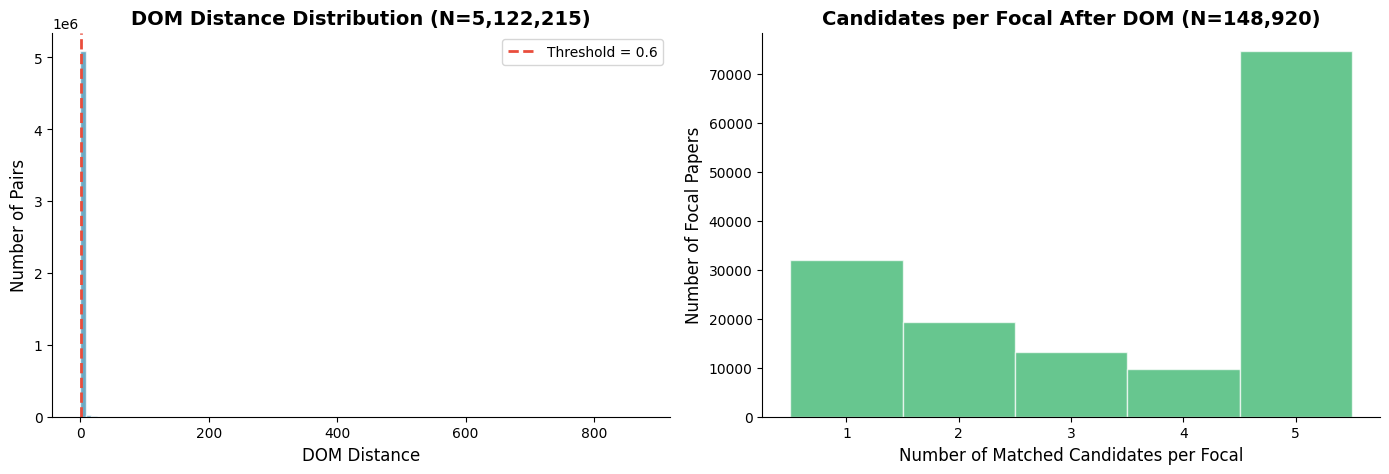

图片已保存


In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左: 全量 DOM 距离分布
ax = axes[0]
ax.hist(df_dom['dom_distance'], bins=100, color='#2E86AB', edgecolor='white', alpha=0.7)
ax.axvline(THRESHOLD, color='#E94D3C', linestyle='--', linewidth=2,
           label=f'Threshold = {THRESHOLD}')
ax.set_xlabel('DOM Distance', fontsize=12)
ax.set_ylabel('Number of Pairs', fontsize=12)
ax.set_title(f'DOM Distance Distribution (N={len(df_dom):,})', fontsize=14, weight='bold')
ax.legend()
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# 右: 每 focal 保留的候选数分布
ax = axes[1]
counts = df_best.groupby('exp_id').size()
ax.hist(counts, bins=range(1, MAX_MATCHES+2), color='#27AE60', edgecolor='white', alpha=0.7, align='left')
ax.set_xlabel('Number of Matched Candidates per Focal', fontsize=12)
ax.set_ylabel('Number of Focal Papers', fontsize=12)
ax.set_title(f'Candidates per Focal After DOM (N={n_focal_matched:,})', fontsize=14, weight='bold')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/Data4/yutao_wen/processed/DOM_Distance_Distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'图片已保存')

## Step 5: 保存 DOM 筛选结果

In [62]:
# 注册到 DuckDB
con.execute('CREATE OR REPLACE TABLE dom_matches AS SELECT * FROM df_best')

output_path = '/Data4/yutao_wen/processed/df_dom_matches.csv'
df_best.to_csv(output_path, index=False)
size_mb = os.path.getsize(output_path) / 1024 / 1024

print(f'已保存: {output_path}')
print(f'大小: {size_mb:.1f} MB')
print(f'配对数: {len(df_best):,}')
print(f'匹配 focal: {n_focal_matched:,}')

print(f'\n删除汇报:')
print(f'  原始配对 (df_match): {len(pairs):,}')
print(f'  跳过 (focal 引用全零): {zero_cite_pairs:,}')
print(f'  DOM 距离 > {THRESHOLD}: {len(df_dom) - len(df_pass):,}')
print(f'  每个 focal 只保留 top {MAX_MATCHES}: {len(df_pass) - len(df_best):,}')
print(f'  最终保留: {len(df_best):,} 对 ({len(df_best)/len(pairs)*100:.1f}%)')
print(f'\n模块(四) DOM 完成!')

已保存: /Data4/yutao_wen/processed/df_dom_matches.csv
大小: 28.1 MB
配对数: 522,543
匹配 focal: 148,920

删除汇报:
  原始配对 (df_match): 8,035,715
  跳过 (focal 引用全零): 2,913,500
  DOM 距离 > 0.6: 1,870,850
  每个 focal 只保留 top 5: 2,728,822
  最终保留: 522,543 对 (6.5%)

模块(四) DOM 完成!


## 快速恢复: 从磁盘加载前面模块的输出

**用途:** kernel 重启后运行此 cell，自动加载所有已保存的 CSV，跳过耗时步骤
**加载:** panel_raw, dom_matches, focals, df_match


In [3]:
# ====== 快速恢复: 从磁盘加载模块(三)(四)输出 ======
# kernel 重启后不需要重跑 JSON 加载
import os
processed = "/Data4/yutao_wen/processed"

# 1. panel_raw (128M 行)
panel_path = os.path.join(processed, "panel_raw.csv")
if os.path.exists(panel_path):
    print("加载 panel_raw.csv (128M行)...")
    con.execute(f"CREATE OR REPLACE TABLE panel_raw AS SELECT * FROM read_csv_auto('{panel_path}')")
    n = con.execute("SELECT COUNT(*) FROM panel_raw").fetchone()[0]
    print(f"  已加载: {n:,} 行")
else:
    print("panel_raw.csv 不存在! 需要从模块(三)重新生成")

# 2. DOM 匹配结果
dom_path = os.path.join(processed, "df_dom_matches.csv")
if os.path.exists(dom_path):
    print("加载 df_dom_matches.csv...")
    con.execute(f"CREATE OR REPLACE TABLE dom_matches AS SELECT * FROM read_csv_auto('{dom_path}')")
    n = con.execute("SELECT COUNT(*) FROM dom_matches").fetchone()[0]
    print(f"  已加载: {n:,} 对")

# 3. focals 表
focal_path = os.path.join(processed, "df_containretra3.csv")
if os.path.exists(focal_path):
    con.execute(f"CREATE OR REPLACE TABLE focals AS SELECT * FROM read_csv_auto('{focal_path}')")
    print("  已加载 focals 表")

# 5. focals_full (含 NumA/NumR) — 从模块(二)输出重建
match_path2 = os.path.join(processed, "df_match.csv")
if os.path.exists(match_path2):
    con.execute("CREATE OR REPLACE TABLE df_match_with_ryear AS SELECT * FROM read_csv_auto('" + match_path2 + "')")
    # 从 df_match 提取 focals_full
    con.execute("""
        CREATE OR REPLACE TEMP TABLE focals_full AS
        SELECT DISTINCT exp_id AS id, f_NumA AS NumA, f_NumR AS NumR,
               Journal_id, PYear
        FROM df_match_with_ryear
    """)
    n = con.execute("SELECT COUNT(*) FROM focals_full").fetchone()[0]
    print(f"  已重建 focals_full: {n:,} 行")
else:
    print("df_match.csv 不存在!")

# 4. df_match (需要 all_papers 特征)
match_path = os.path.join(processed, "df_match.csv")
if os.path.exists(match_path):
    con.execute(f"CREATE OR REPLACE TABLE df_match_with_ryear AS SELECT * FROM read_csv_auto('{match_path}')")
    print("  已加载 df_match 表")

print("\n快速恢复完成! 可以继续跑模块(五)了")


加载 panel_raw.csv (128M行)...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  已加载: 128,504,674 行
加载 df_dom_matches.csv...
  已加载: 522,543 对
  已加载 focals 表


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  已重建 focals_full: 217,524 行
  已加载 df_match 表

快速恢复完成! 可以继续跑模块(五)了


---

# 模块(五): 展开面板 + 新增控制变量

**参考:** Azoulay et al. (2019, AER) 的控制变量选择
**新增控制:** 撤稿前引用存量、numa/numr level项、field FE、期刊影响力、撤稿严重性

## Step 1: 加载 DOM 匹配结果 + 合并面板引用数据

In [14]:
print('加载 DOM 匹配结果...')
df_dom = pd.read_csv('/Data4/yutao_wen/processed/df_dom_matches.csv')
print(f'DOM 配对数: {len(df_dom):,}')

# 注册到 DuckDB
con.execute('CREATE OR REPLACE TABLE dom_matches AS SELECT * FROM df_dom')

n_foc = con.execute('SELECT COUNT(DISTINCT exp_id) FROM dom_matches').fetchone()[0]
n_cand = con.execute('SELECT COUNT(DISTINCT ctrl_id) FROM dom_matches').fetchone()[0]
print(f'唯一 focal: {n_foc:,}')
print(f'唯一 candidate: {n_cand:,}')

# 从 panel_raw 拿引用数据, 只取 DOM 需要的
print('提取面板引用数据...')
con.execute('''
    CREATE OR REPLACE TEMP TABLE focal_panel AS
    SELECT p.* FROM panel_raw p
    WHERE p.group_val = 1 AND p.exp_id IN (SELECT exp_id FROM dom_matches)
''')
con.execute('''
    CREATE OR REPLACE TEMP TABLE cand_panel AS
    SELECT p.* FROM panel_raw p
    WHERE p.group_val = 0 AND p.ctrl_id IN (SELECT ctrl_id FROM dom_matches)
''')
n_fp = con.execute('SELECT COUNT(*) FROM focal_panel').fetchone()[0]
n_cp = con.execute('SELECT COUNT(*) FROM cand_panel').fetchone()[0]
print(f'Focal 面板行: {n_fp:,}, Candidate 面板行: {n_cp:,}')

加载 DOM 匹配结果...
DOM 配对数: 522,543
唯一 focal: 148,920
唯一 candidate: 492,020
提取面板引用数据...
Focal 面板行: 45,147,100, Candidate 面板行: 9,447,156


## Step 2: 展开面板 — 仿旧版格式

对每对 (focal, candidate), 展开 PYear~2023 的每一年:
- 实验组 (group=1): focal 自己的引用
- 控制组 (group=0): candidate 的引用

In [15]:
# 用 CREATE TABLE 替代 ALTER+UPDATE (避免 2.2亿行更新卡死)
con.execute('DROP TABLE IF EXISTS panel_expanded2')
con.execute('''
    CREATE TABLE panel_expanded2 AS
    SELECT *,
        CASE WHEN year < RYear THEN 1 ELSE 0 END AS pd
    FROM panel_expanded
''')
con.execute('DROP TABLE IF EXISTS panel_expanded')
con.execute('ALTER TABLE panel_expanded2 RENAME TO panel_expanded')
print('已添加 pd 列 (事前 dummy)')


正在展开面板...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

面板行数: 219,599,596
耗时: 0.1 分钟


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

面板变量: pair, focal_id, paper_id, group_val, year, yearlycitation, log_yearlycitation, PYear, RYear, treated, post, did, pd, dom_distance


## Step 3: 添加控制变量 (参考 Azoulay 2019)

### 3a: 基础论文特征 (numa, numr, journal_id)

从 Papers.csv 获取 (已有 focals_full 表)

In [16]:
# 3a: 从 focals_full + df_match 提取特征
print('正在提取论文特征...')

# focals: focal 的特征 (NumA, NumR, Journal_id, PYear)
# df_match_with_ryear: candidate 的特征

# 收集所有 paper_id
con.execute('CREATE OR REPLACE TEMP TABLE all_pids AS SELECT DISTINCT focal_id AS paper_id FROM panel_expanded UNION SELECT DISTINCT paper_id FROM panel_expanded')

# Focal 特征
con.execute('''
    CREATE OR REPLACE TEMP TABLE paper_features AS
    SELECT f.id AS paper_id, f.NumA AS numa, f.NumR AS numr, f.Journal_id AS journal_id
    FROM focals_full f
    WHERE f.id IN (SELECT paper_id FROM all_pids)
''')

# Candidate 特征 (从 df_match_with_ryear)
con.execute('''
    INSERT INTO paper_features
    SELECT DISTINCT m.ctrl_id AS paper_id, m.f_NumA AS numa, m.f_NumR AS numr, m.Journal_id AS journal_id
    FROM df_match_with_ryear m
    WHERE m.ctrl_id IN (SELECT paper_id FROM all_pids)
      AND m.ctrl_id NOT IN (SELECT paper_id FROM paper_features)
''')

n_pf = con.execute('SELECT COUNT(*) FROM paper_features').fetchone()[0]
n_miss = con.execute('SELECT COUNT(*) FROM all_pids WHERE paper_id NOT IN (SELECT paper_id FROM paper_features)').fetchone()[0]
print(f'  paper_features: {n_pf:,}, 缺失: {n_miss:,}')

# 合并
con.execute('''
    CREATE OR REPLACE TABLE panel_with_cov AS
    SELECT e.*, pf.numa, pf.numr, pf.journal_id
    FROM panel_expanded e
    LEFT JOIN paper_features pf ON e.paper_id = pf.paper_id
''')
# Self-retraction flag
con.execute('''
    CREATE OR REPLACE TABLE panel_with_cov AS
    SELECT *,
        CASE WHEN focal_id IN (SELECT id FROM focals WHERE is_self_retracted) THEN 1 ELSE 0 END AS selfretra
    FROM panel_with_cov
''')
n_self = con.execute('SELECT COUNT(DISTINCT focal_id) FROM panel_with_cov WHERE selfretra=1').fetchone()[0]
print(f'  Self-retracted focals: {n_self:,}')
print('  基础特征已添加: numa, numr, journal_id, selfretra')


正在提取论文特征...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  paper_features: 986,190, 缺失: 0


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  基础特征已添加: numa, numr, journal_id


### 3b: 撤稿前引用存量 (Azoulay 2019: baseline citation stock)

在撤稿年份之前, focal/candidate 累积被引多少?

In [17]:
# 3b: 撤稿前引用存量 — 用 CREATE TABLE 替代 UPDATE
print('正在计算撤稿前引用存量...')

# 计算 pre-retraction total cites
con.execute('''
    CREATE OR REPLACE TEMP TABLE pre_retra_cites AS
    SELECT paper_id, focal_id, group_val,
           SUM(yearlycitation) AS pre_cites_total,
           AVG(yearlycitation) AS pre_cites_avg
    FROM panel_with_cov
    WHERE year < RYear
    GROUP BY paper_id, focal_id, group_val
''')

# 一次性建新表 (避免 UPDATE 2.2亿行)
con.execute('DROP TABLE IF EXISTS panel_with_cov2')
con.execute('''
    CREATE TABLE panel_with_cov2 AS
    SELECT p.*,
        COALESCE(c.pre_cites_total, 0) AS pre_cites_total,
        COALESCE(c.pre_cites_avg, 0) AS pre_cites_avg
    FROM panel_with_cov p
    LEFT JOIN pre_retra_cites c
      ON p.paper_id = c.paper_id AND p.group_val = c.group_val
''')

desc = con.execute('SELECT AVG(pre_cites_total), MEDIAN(pre_cites_total), MAX(pre_cites_total) FROM panel_with_cov2').fetchone()
print(f'Pre-retraction total cites: mean={desc[0]:.1f}, median={desc[1]:.0f}, max={desc[2]:.0f}')
print('控制变量已添加: pre_cites_total, pre_cites_avg')

# 保存检查点
import os
ckpt = '/Data4/yutao_wen/processed/panel_checkpoint_3b.csv'
print(f'保存检查点到 {ckpt}...')
con.execute(f"COPY panel_with_cov2 TO '{ckpt}' (HEADER, DELIMITER ',')")
print(f'检查点已保存: {os.path.getsize(ckpt)/1024/1024/1024:.1f} GB')


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Pre-retraction total cites: mean=64946.2, median=17370, max=5121984


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

控制变量已添加: pre_cites_total, pre_cites_avg
检查点已保存: /Data4/yutao_wen/processed/panel_checkpoint_3b.csv


### 3c: 对数控制变量 (level项, 不只是trend)
# 用 CREATE TABLE AS SELECT 替代 ALTER+UPDATE — 2.2亿行秒级完成
print('正在计算对数控制变量...')
t0 = time.time()

con.execute('DROP TABLE IF EXISTS panel_with_cov3')
con.execute('''
    CREATE TABLE panel_with_cov3 AS
    SELECT *,
        ln(1 + numa) AS log_numa,
        ln(1 + numr) AS log_numr,
        ln(1 + pre_cites_total) AS log_pre_cites,
        (year - PYear) AS age,
        -- 时间趋势交互项
        ln(1 + numa) * year / 100 AS author_year,
        ln(1 + numr) * year / 100 AS ref_year,
        selfretra * year / 100 AS sef_year
    FROM panel_with_cov2
''')

n = con.execute('SELECT COUNT(*) FROM panel_with_cov3').fetchone()[0]
print(f'  面板行数: {n:,}')
print(f'  耗时: {(time.time()-t0)/60:.1f} 分钟')
print('  已添加: log_numa, log_numr, log_pre_cites, age, author_year, ref_year, sef_year')


### 3d: paper_numid (Stata 面板需要的数字 ID)

In [ ]:
con.execute('''
    CREATE OR REPLACE TABLE panel_final AS
    SELECT *,
        DENSE_RANK() OVER (ORDER BY paper_id) AS paper_numid
    FROM panel_with_cov2
''')

n = con.execute('SELECT COUNT(*) FROM panel_final').fetchone()[0]
n_focal = con.execute('SELECT COUNT(DISTINCT focal_id) FROM panel_final').fetchone()[0]
n_paper = con.execute('SELECT COUNT(DISTINCT paper_id) FROM panel_final').fetchone()[0]
n_pair = con.execute('SELECT COUNT(DISTINCT pair) FROM panel_final').fetchone()[0]

print(f'面板行数: {n:,}')
print(f'Unique focal: {n_focal:,}')
print(f'Unique paper: {n_paper:,}')
print(f'Unique pair: {n_pair:,}')
print(f'平均每 focal 候选: {n_pair/n_focal:.1f}')

## Step 4: 保存面板

In [ ]:
output_path = '/Data4/yutao_wen/processed/DOM_panel_final.csv'
print(f'正在保存到 {output_path}...')
con.execute(f"COPY panel_final TO '{output_path}' (HEADER, DELIMITER ',')")
size_mb = os.path.getsize(output_path) / 1024 / 1024

# 列名
cols = con.execute('DESCRIBE panel_final').df()
print(f'已保存: {output_path}')
print(f'行数: {n:,}')
print(f'大小: {size_mb:.1f} MB')
print(f'\n列名: {list(cols["column_name"])}')

print(f'\n模块(五) 完成! 下一步: Stata 回归')